### Challenge 4: Classical Two-Bit Adder

**Objective:** Design a Qiskit program with a 4-qubit quantum circuit that implements a reversible binary adder using multi-qubit gates ($CX$ and $CCX$) to mimic the logic of a classical digital half-adder circuit.

---

#### A: Truth Table Analysis
Your quantum circuit must process two input qubits ($A$ and $B$) and manipulate two output qubits ($Sum$ and $Carry\text{-}out$) to match the exact behavior of classical digital adder logic:

| Input $A$ | Input $B$ | Expected Sum Bit | Expected Carry-out Bit | Binary Result / Arithmetic |
| :---: | :---: | :---: | :---: | :--- |
| $0$ | $0$ | $0$ | $0$ | $00_2 \rightarrow 0 + 0 = 0$ |
| $0$ | $1$ | $1$ | $0$ | $01_2 \rightarrow 0 + 1 = 1$ |
| $1$ | $0$ | $1$ | $0$ | $01_2 \rightarrow 1 + 0 = 1$ |
| $1$ | $1$ | $0$ | $1$ | $10_2 \rightarrow 1 + 1 = 2$ |

*Note: In classical circuits, the Sum bit is computed using an **XOR** gate, and the Carry-out bit is computed using an **AND** gate. Your task is to identify which multi-qubit quantum gates perfectly map to these classical operations.*

#### B: Circuit Setup & The Logic Puzzle
Construct a quantum system using four qubits structured as follows:
* **`q0` and `q1` (Inputs $A$ and $B$):** Use initialization gates (such as the Pauli-$X$ gate) to configure these qubits into any of the four possible input states listed in Part A to test your solution.
* **`q2` (Sum Bit):** Acts as the target register for the addition modulo 2 ($A \oplus B$).
* **`q3` (Carry-out Bit):** Acts as the target register for the overflow column bit ($A \cdot B$).

Determine the exact sequence of multi-qubit operations needed in the middle section of the circuit to map the data from your input registers over to the output registers without destructively altering the core input values.

#### C: Execution and Verification
Insert your logic assembly directly into the middle segment of your notebook file template, run the script, and evaluate the measurement outcomes.

* **Validation Constraint:** Ensure that when inputs are set to $|11\rangle$, the measurement cleanly yields a $1$ on the carry-out line and a $0$ on the sum line, maintaining full state reversibility.


In [3]:
from qiskit import *
from qiskit import transpile
from qiskit.visualization import plot_histogram, array_to_latex, plot_bloch_multivector
from qiskit_aer import Aer
from qiskit.quantum_info.states import statevector
from qiskit.transpiler import AnalysisPass
from math import pi
import matplotlib.pyplot as plt

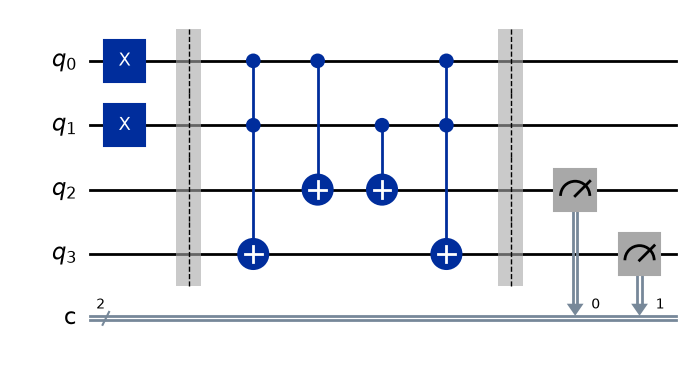

In [4]:
# 1. Initialize a circuit with 4 qubits and 2 classical bits
circuit = QuantumCircuit(4, 2)
circuit.x(0) # initialize input A
circuit.x(1) # initialize input B
circuit.barrier()


circuit.ccx(0, 1, 3)

# Use CNOT gates to compute XOR logic: check inputs to update SUM(2)
circuit.cx(0, 2) #Control to conditionally flip the sum qubit
circuit.cx(1, 2) #Control for flipping the sum
circuit.ccx(0, 1, 3) # Toffoli gate to use the first two input qubits as controls and flip the fourth carryout qubit accordingly.

circuit.barrier()
circuit.measure(2, 0) # measure SUM
circuit.measure(3, 1) # measure CARRY-OUT
circuit.draw(output='mpl')


If only one of the inputs is one then the sum will be flipped once ending up in the one state. However, if both inputs are one, then both CNOT gates would be triggered flipping the sum from zero to one and then from one back to zero. T

In [5]:
simulator = Aer.get_backend('statevector_simulator')
compiled = transpile(circuit, simulator)
result = simulator.run(compiled).result()
statevector = result.get_statevector()
array_to_latex(statevector)

<IPython.core.display.Latex object>

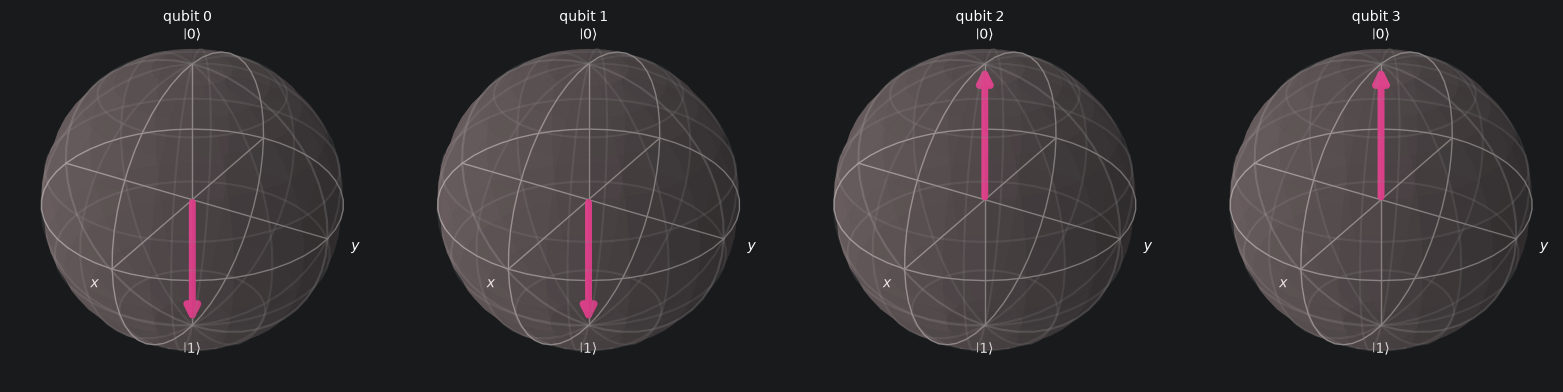

In [6]:
plot_bloch_multivector(statevector)